# 99 — Atlas map

Static choropleth of the livability score, plus an interactive re-weighting widget to see how weight changes shift the map.

In [9]:
import matplotlib.pyplot as plt
import xarray as xr

from common import PROCESSED_DIR, load_weights, weighted_score

## Load

In [10]:
score = xr.open_dataarray(PROCESSED_DIR / 'score.nc')

## Static map

Text(0.5, 1.0, 'World livability atlas')

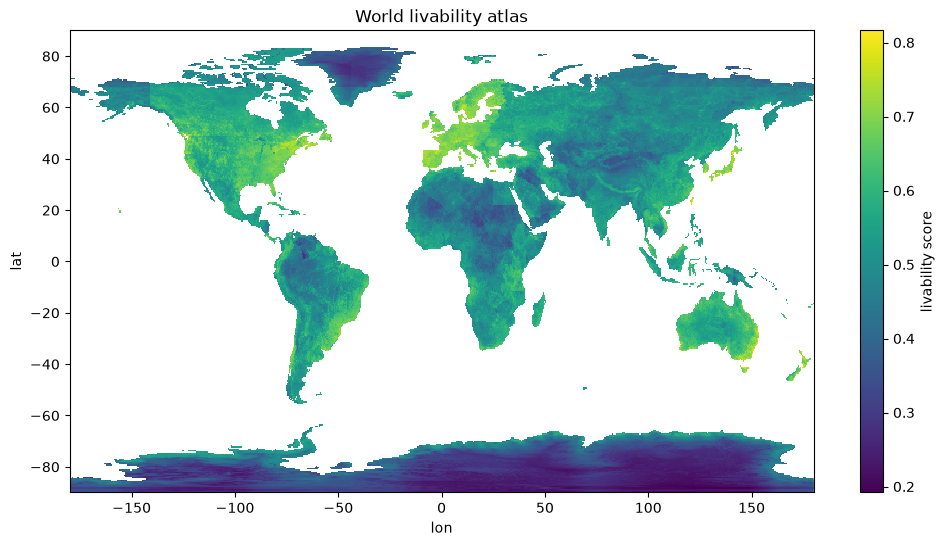

In [11]:
fig, ax = plt.subplots(figsize=(12, 6))
score.plot(ax=ax, cmap='viridis', cbar_kwargs={'label': 'livability score'})
ax.set_title('World livability atlas')

## Interactive re-weighting

Sliders per variable rebuild the score on the fly. Uses raw (un-normalized) weights so the slider values match `weights.yaml`.

Three preference dropdowns swap the underlying scoring recipe for the layers that have a tunable "ideal" parameter:

- **climate** — recomputes `temperature_pleasantness` around a chosen ideal temperature and tolerance band.
- **rainfall** — recomputes `precipitation_balance` around a chosen monthly-precipitation target.
- **density** — recomputes `population_density` around a chosen preferred density (log-space tolerance).

For each dropdown option, the layer is percentile-ranked at cell-top the same way `92_normalization.ipynb` does, so it composes fairly with the other pre-normalized layers. All variants are cached, so switching a dropdown is a dict lookup — no recompute.

In [ ]:
import ipywidgets as widgets
import numpy as np
from IPython.display import display
from scipy.stats import rankdata

from common import (
    compute_population_density_score,
    compute_precipitation_balance,
    compute_temperature_pleasantness,
)


def percentile_rank(da):
    """Rank-transform a DataArray to percentiles in ``[0, 1]``.

    Mirrors the helper in ``92_normalization.ipynb`` so the recomputed
    preference layers compose fairly with the pre-normalized layers in
    ``normalized.nc``. Ties averaged, NaN cells preserved.
    """
    values = da.values.astype(float)
    flat = values.ravel()
    mask = np.isfinite(flat)
    out = np.full_like(flat, np.nan)
    n = int(mask.sum())
    if n > 1:
        out[mask] = (rankdata(flat[mask], method='average') - 1) / (n - 1)
    elif n == 1:
        out[mask] = 0.0
    return da.copy(data=out.reshape(values.shape))


TEMP_PROFILES = {
    'Cool (15°C ±8)':       (15.0, 8.0),
    'Temperate (20°C ±10)': (20.0, 10.0),
    'Warm (25°C ±8)':       (25.0, 8.0),
    'Tropical (27°C ±5)':   (27.0, 5.0),
}
PRECIP_PROFILES = {
    'Arid (20mm ±20)':       (20.0, 20.0),
    'Balanced (80mm ±60)':   (80.0, 60.0),
    'Wet (150mm ±60)':       (150.0, 60.0),
    'Very wet (250mm ±80)':  (250.0, 80.0),
}
# Wilderness uses mode='at_most' so genuinely empty cells score at the top
# rather than being penalised for falling below the "ideal" 0.1 people/km².
DENSITY_PROFILES = {
    'Wilderness (≤0.1/km² ±1dec)': (0.1,    1.0, 'at_most'),
    'Rural (30/km² ±1dec)':        (30.0,   1.0, 'centered'),
    'Suburban (500/km² ±1dec)':    (500.0,  1.0, 'centered'),
    'Urban (3000/km² ±1dec)':      (2000.0, 1.0, 'at_least'),
}
DEFAULT_TEMP    = 'Temperate (20°C ±10)'
DEFAULT_PRECIP  = 'Balanced (80mm ±60)'
DEFAULT_DENSITY = 'Suburban (500/km² ±1dec)'

raw_weights = load_weights()
ds = xr.open_dataset(PROCESSED_DIR / 'normalized.nc')
layers = {name: ds[name] for name in raw_weights if name in ds.data_vars}

# Precompute a percentile-ranked layer per preference profile so each dropdown
# callback is a dict lookup rather than a recompute.
_at_source      = PROCESSED_DIR / '_apparent_temp_monthly.nc'
_precip_source  = PROCESSED_DIR / '_precipitation_monthly.nc'
_density_source = PROCESSED_DIR / '_population_density.nc'

TEMP_LAYERS = {
    label: percentile_rank(
        compute_temperature_pleasantness(source=_at_source, ideal_temp=t, tolerance=tol)
    )
    for label, (t, tol) in TEMP_PROFILES.items()
}
PRECIP_LAYERS = {
    label: percentile_rank(
        compute_precipitation_balance(source=_precip_source, ideal_monthly_mm=m, tolerance_mm=tol)
    )
    for label, (m, tol) in PRECIP_PROFILES.items()
}
DENSITY_LAYERS = {
    label: percentile_rank(
        compute_population_density_score(source=_density_source, ideal_density=d, tolerance_decades=tol, mode=mode)
    )
    for label, (d, tol, mode) in DENSITY_PROFILES.items()
}

temp_profile = widgets.Dropdown(
    options=list(TEMP_PROFILES), value=DEFAULT_TEMP, description='climate',
)
precip_profile = widgets.Dropdown(
    options=list(PRECIP_PROFILES), value=DEFAULT_PRECIP, description='rainfall',
)
density_profile = widgets.Dropdown(
    options=list(DENSITY_PROFILES), value=DEFAULT_DENSITY, description='density',
)
sliders = {
    name: widgets.FloatSlider(value=raw_weights[name], min=0, max=2, step=0.1, description=name[:15])
    for name in layers
}

# Setting each slider fires interact's redraw, so zeroing 18 sliders triggers
# a burst of redraws. Sliders already at 0 are skipped by ipywidgets (no
# observer fires when the value doesn't change), so the cost is bounded by
# the number of non-zero sliders at click time.
reset_button = widgets.Button(description='Zero all weights', button_style='warning')

def _zero_all_weights(_):
    for s in sliders.values():
        s.value = 0

reset_button.on_click(_zero_all_weights)
display(reset_button)


def redraw(temp_profile, precip_profile, density_profile, **kw):
    layers_live = {
        **layers,
        'temperature_pleasantness': TEMP_LAYERS[temp_profile],
        'precipitation_balance':    PRECIP_LAYERS[precip_profile],
        'population_density':       DENSITY_LAYERS[density_profile],
    }
    active = {k: w for k, w in kw.items() if w > 0}
    fig, ax = plt.subplots(figsize=(12, 6))
    if active:
        weighted_score({k: layers_live[k] for k in active}, active).plot(ax=ax, cmap='viridis')
    plt.show()


widgets.interact(
    redraw,
    temp_profile=temp_profile,
    precip_profile=precip_profile,
    density_profile=density_profile,
    **sliders,
)